## Objective

The objective of this project to develop a machine learning based classification model that predicts the geopolitical state between two contries using multi-dimensional feautures. the model aims to classify the relationship into multiple categories:peace,strategic competetion, cold war, proxy war and direct war. Based on factors such as miltitary strength, nuclear capability, economic contiditions, ideaological diffrences, political stability, historical conflicts and sentiment anaylysis derived from media and public discourses. this study further seeks to : 1. Identify and enjineer meaningful features that influnces geopolitical tensions. 2. Analysyse the impact of different factors on conflict escalation. Build and evaluate a neural network model using proper data preprocessing,validation and testing techniques. 3. Optimise model performance through hyper parameter tuning and validation strategies. Ultimately the goal is to create a predictive framework that can assist in understanding and forcasting global conflicts dynamics using data driven approach. 

In [136]:
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense, Dropout

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [137]:
df = pd.read_csv("geopolitical_dataset.csv")

In [138]:
df.shape

(1000, 15)

In [139]:
df.head()

,military_power_ratio,troop_movement,nuclear_capability,nuclear_warheads,gdp_ratio,sanctions_intensity,trade_dependency,ideology_distance,political_stability,historical_conflict,border_distance,news_sentiment,nationalism_index,leader_aggression,target
0,1.061810,46,0,20,1.514162,7,0.949273,0.844864,0.934033,5,793.537402,-0.740587,0.084002,0.274637,1
1,1.926071,11,0,157,1.915973,7,0.879601,0.359676,0.766351,6,85.599553,-0.092492,0.681526,0.273081,1
2,1.597991,61,0,268,0.903452,9,0.907042,0.687234,0.657950,0,183.457885,0.013860,0.680110,0.302622,1
3,1.397988,79,0,161,1.213110,6,0.991533,0.312834,0.823896,0,758.403673,0.374780,0.669080,0.612313,1
4,0.734028,87,1,259,1.451510,4,0.208315,0.060906,0.647520,4,21.986522,0.266567,0.942334,0.438333,1


In [140]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   military_power_ratio  1000 non-null   float64
 1   troop_movement        1000 non-null   int64  
 2   nuclear_capability    1000 non-null   int64  
 3   nuclear_warheads      1000 non-null   int64  
 4   gdp_ratio             1000 non-null   float64
 5   sanctions_intensity   1000 non-null   int64  
 6   trade_dependency      1000 non-null   float64
 7   ideology_distance     1000 non-null   float64
 8   political_stability   1000 non-null   float64
 9   historical_conflict   1000 non-null   int64  
 10  border_distance       1000 non-null   float64
 11  news_sentiment        1000 non-null   float64
 12  nationalism_index     1000 non-null   float64
 13  leader_aggression     1000 non-null   float64
 14  target                1000 non-null   int64  
dtypes: float64(9), int64(6

In [141]:
df.describe()

,military_power_ratio,troop_movement,nuclear_capability,nuclear_warheads,gdp_ratio,sanctions_intensity,trade_dependency,ideology_distance,political_stability,historical_conflict,border_distance,news_sentiment,nationalism_index,leader_aggression,target
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,1.235385,49.160000,0.529000,253.442000,1.279245,4.597000,0.498373,0.497929,0.489480,4.496000,492.823847,-0.018263,0.517017,0.497426,1.595000
std,0.438206,29.131204,0.499408,143.414142,0.425925,2.844412,0.287361,0.289664,0.287191,2.930285,280.927662,0.570455,0.285276,0.295820,0.776903
min,0.506948,0.000000,0.000000,0.000000,0.500664,0.000000,0.000227,0.003918,0.000241,0.000000,0.052827,-0.999518,0.002141,0.000158,0.000000
25%,0.853960,24.000000,0.000000,130.750000,0.927437,2.000000,0.255222,0.245255,0.240101,2.000000,257.662524,-0.511212,0.280303,0.241523,1.000000
50%,1.245211,47.000000,1.000000,259.000000,1.296736,5.000000,0.483831,0.500748,0.481948,5.000000,490.355372,-0.011218,0.523833,0.484278,2.000000
75%,1.616479,75.000000,1.000000,380.250000,1.643959,7.000000,0.749492,0.745443,0.741773,7.000000,724.534469,0.471912,0.765292,0.762728,2.000000
max,1.999577,99.000000,1.000000,499.000000,1.999316,9.000000,0.998793,0.999461,0.999207,9.000000,996.990503,0.999010,0.999673,0.999335,4.000000


In [142]:
X = df.drop(columns=['target'])
y = df['target']
print(X.shape)
print(y.shape)

(1000, 14)
(1000,)


In [143]:
y

0      1
1      1
2      1
3      1
4      1
      ..
995    1
996    2
997    1
998    2
999    1
Name: target, Length: 1000, dtype: int64

In [144]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

10,50,70,90 % per split krke try karna hai 

In [145]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [146]:
len(np.unique(y))

5

In [147]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),

    Dense(len(np.unique(y)), activation='softmax')
])

c:\Users\manis\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [148]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [149]:
# model = Sequential([
#     Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
#     Dropout(0.3),
    
#     Dense(64, activation='relu'),
#     Dropout(0.3),
#     Dense(32, activation='relu'),

#     Dense(len(np.unique(y)), activation='linear')
# ])

In [150]:
# model.compile(
#     optimizer='adam',
#     loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
#     metrics=['accuracy']
# )

In [151]:
import time

start = time.time()

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
)

end = time.time()
print(f"Training Time: {end - start:.2f} seconds")

Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4114 - loss: 1.4175 - val_accuracy: 0.5133 - val_loss: 1.2653
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5629 - loss: 1.1426 - val_accuracy: 0.6400 - val_loss: 1.1016
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6414 - loss: 1.0297 - val_accuracy: 0.6733 - val_loss: 0.9587
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6657 - loss: 0.9067 - val_accuracy: 0.6800 - val_loss: 0.7970
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7057 - loss: 0.7875 - val_accuracy: 0.7667 - val_loss: 0.6590
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7657 - loss: 0.6679 - val_accuracy: 0.8067 - val_loss: 0.5288
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7929 - loss: 0.5657 - val_accuracy: 0.8133 - val_loss: 0.4477
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7957 - loss: 0.5264 - val_accuracy: 0.8733 - 

In [152]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9467 - loss: 0.1851
Test Accuracy: 0.9466666579246521


From Logits=true = 27 seconds, not true = 30 seonds

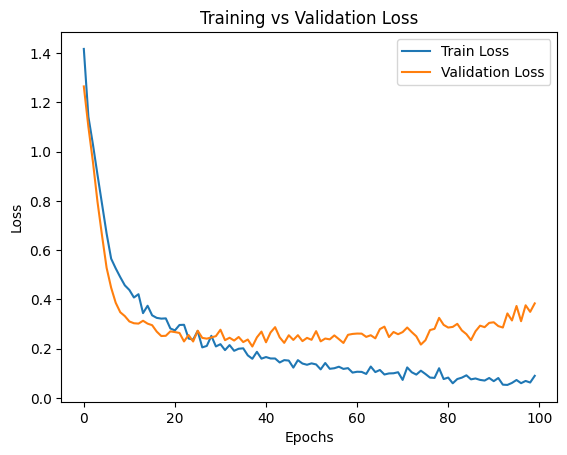

In [153]:
plt.figure()

plt.plot(history.history['loss'],label='Train Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.title("Training vs Validation Loss")

plt.show()

In [154]:
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test Loss",test_loss)
print("Test Accuracy",test_acc)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9467 - loss: 0.1851
Test Loss 0.18510131537914276
Test Accuracy 0.9466666579246521


In [155]:
print(df['target'].value_counts())

target
1    438
2    383
3    129
0     49
4      1
Name: count, dtype: int64


In [156]:
class_names = ['Peace', 'Strategic', 'Cold War', 'Proxy War', 'Direct War']

In [157]:
counts = df['target'].value_counts().sort_index()

for i in range(len(counts)):
    print(f"{class_names[i]}: {counts[i]}")

Peace: 49
Strategic: 438
Cold War: 383
Proxy War: 129
Direct War: 1


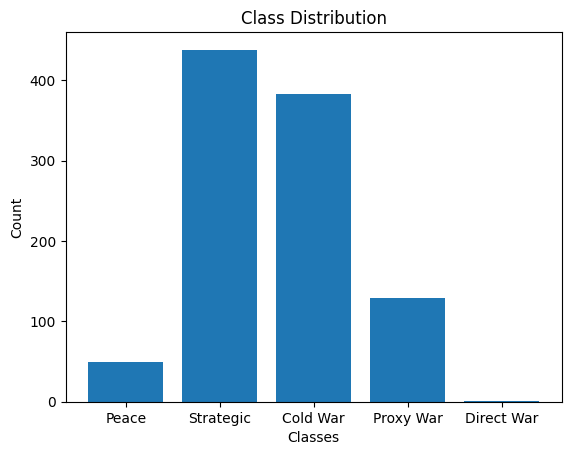

In [158]:
class_names = ['Peace', 'Strategic', 'Cold War', 'Proxy War', 'Direct War']

counts = df['target'].value_counts().sort_index()

plt.figure()
plt.bar(class_names, counts.values)
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Count")
plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


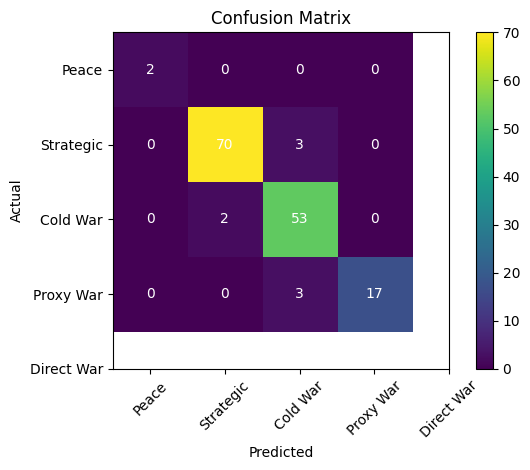

In [159]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)


plt.figure()
plt.imshow(cm)
plt.colorbar()


plt.xticks(ticks=np.arange(len(class_names)), labels=class_names, rotation=45)
plt.yticks(ticks=np.arange(len(class_names)), labels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i][j], ha='center', va='center', color='white')

plt.tight_layout()
plt.show()

In [160]:
print(classification_report(y_test, y_pred_classes))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       0.97      0.96      0.97        73
           2       0.90      0.96      0.93        55
           3       1.00      0.85      0.92        20

    accuracy                           0.95       150
   macro avg       0.97      0.94      0.95       150
weighted avg       0.95      0.95      0.95       150

